In [13]:
import requests
import csv
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

START_DATE = "2022-01-01"
END_DATE = "2025-12-31"

csv_filename = "sbh_train_data_archive.csv"

In [14]:
locations = [
    {"name": "Suoi Trai", "lat": 13.097145, "lon": 108.846860},
    {"name": "Krong Nang", "lat": 13.067, "lon": 108.798},
    {"name": "Ea Ly", "lat": 12.981, "lon": 108.825},
    {"name": "Buon Sai", "lat": 13.1378, "lon": 108.7516},
    {"name": "Ia Dreh", "lat": 13.1204, "lon": 108.7097},
    {"name": "Buon Kham", "lat": 13.1108, "lon": 108.7887},
    {"name": "Ea Bar", "lat": 13.0098, "lon": 108.8052}
]

# Các biến cần lấy
hourly_params = "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,cloud_cover_mid,pressure_msl,soil_moisture_0_to_7cm"

all_points_data = []

print(f"Đang load data từ {START_DATE} đến {END_DATE}...")

for loc in locations:
    print(f"{loc['name']} ({loc['lat']}, {loc['lon']}) done..")
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": loc["lat"],
        "longitude": loc["lon"],
        "start_date": START_DATE,
        "end_date": END_DATE,
        "hourly": hourly_params,
        "timezone": "Asia/Bangkok"
    }
    
    response = requests.get(url, params=params)
    if response.status_code == 200:
        all_points_data.append(response.json().get("hourly", {}))
    else:
        print(f"Lỗi khi load điểm {loc['name']}: Error code {response.status_code}")

print("Done")

if len(all_points_data) == len(locations):
    # Lấy mốc thời gian từ điểm đầu tiên
    times = all_points_data[0].get("time", [])

    # Danh sách các key dữ liệu cần tính trung bình
    keys_to_average = [
        "temperature_2m", "relative_humidity_2m", "precipitation", 
        "wind_speed_10m", "wind_direction_10m", "cloud_cover_mid", 
        "pressure_msl", "soil_moisture_0_to_7cm"
    ]
    
    with open(csv_filename, mode='w', newline='', encoding='utf-8-sig') as file:
        writer = csv.writer(file)
        
        writer.writerow([
            "Time", "Temperature (°C)", "Humidity (%)", "Precipitations (mm)", 
            "Wind_speeds (km/h)", "Wind_direction (°)", "Cloud_cover_mid (%)", 
            "Pressure (hPa)", "Soil_moisture_0_7cm (m³/m³)"
        ])

        for i in range(len(times)):
            row_data = [times[i]]
            
            for key in keys_to_average:
                # Lấy giá trị của cùng 1 giờ từ tất cả các điểm, bỏ các giá trị None
                values = []
                for point_data in all_points_data:
                    val = point_data.get(key, [])
                    if i < len(val) and val[i] is not None:
                        values.append(val[i])

                if values:
                    avg_val = round(sum(values) / len(values), 2)
                    row_data.append(avg_val)
                else:
                    row_data.append("N/A") # Nếu cả tất cả đều None
            
            writer.writerow(row_data)
    print(f"Đã lưu vào file: {csv_filename}")
else:
    print("Không đủ data từ 3 điểm đo. Pls check ur API")

Đang load data từ 2022-01-01 đến 2025-12-31...
Suoi Trai (13.097145, 108.84686) done..
Krong Nang (13.067, 108.798) done..
Ea Ly (12.981, 108.825) done..
Buon Sai (13.1378, 108.7516) done..
Ia Dreh (13.1204, 108.7097) done..
Buon Kham (13.1108, 108.7887) done..
Ea Bar (13.0098, 108.8052) done..
Done
Đã lưu vào file: sbh_train_data_archive.csv


In [17]:
df = pd.read_csv(csv_filename)
df = df.replace("N/A", pd.NA)

df['Time'] = pd.to_datetime(df['Time'])
df.set_index('Time', inplace=True)

df = df.astype(float)

print(f"Tổng số dòng dữ liệu: {len(df)}")
display(df.head())

Tổng số dòng dữ liệu: 35064


,Temperature (°C),Humidity (%),Precipitations (mm),Wind_speeds (km/h),Wind_direction (°),Cloud_cover_mid (%),Pressure (hPa),Soil_moisture_0_7cm (m³/m³)
Time,,,,,,,,
2022-01-01 00:00:00,20.33,87.29,0.03,9.27,60.86,24.71,1019.44,0.44
2022-01-01 01:00:00,20.43,87.14,0.06,9.47,52.71,33.57,1018.64,0.44
2022-01-01 02:00:00,20.24,87.57,0.06,8.77,51.71,20.57,1017.74,0.44
2022-01-01 03:00:00,20.34,87.29,0.00,8.79,47.29,34.86,1017.09,0.44
2022-01-01 04:00:00,20.14,88.43,0.00,8.16,57.71,23.86,1017.03,0.44


In [18]:
df.describe()

,Temperature (°C),Humidity (%),Precipitations (mm),Wind_speeds (km/h),Wind_direction (°),Cloud_cover_mid (%),Pressure (hPa),Soil_moisture_0_7cm (m³/m³)
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000
mean,25.644655,79.136547,0.187633,9.318975,160.703880,20.466097,1010.596243,0.382193
std,3.782308,14.845825,0.683853,5.162281,84.026842,27.100553,3.878599,0.078345
min,14.270000,24.430000,0.000000,0.430000,12.430000,0.000000,994.690000,0.220000
25%,23.140000,69.140000,0.000000,5.310000,86.710000,1.140000,1007.830000,0.320000
50%,25.090000,82.430000,0.000000,8.330000,127.710000,9.570000,1010.400000,0.390000
75%,27.860000,91.710000,0.090000,12.460000,247.860000,26.860000,1013.370000,0.450000
max,39.810000,99.860000,15.000000,52.690000,351.290000,100.000000,1023.270000,0.530000


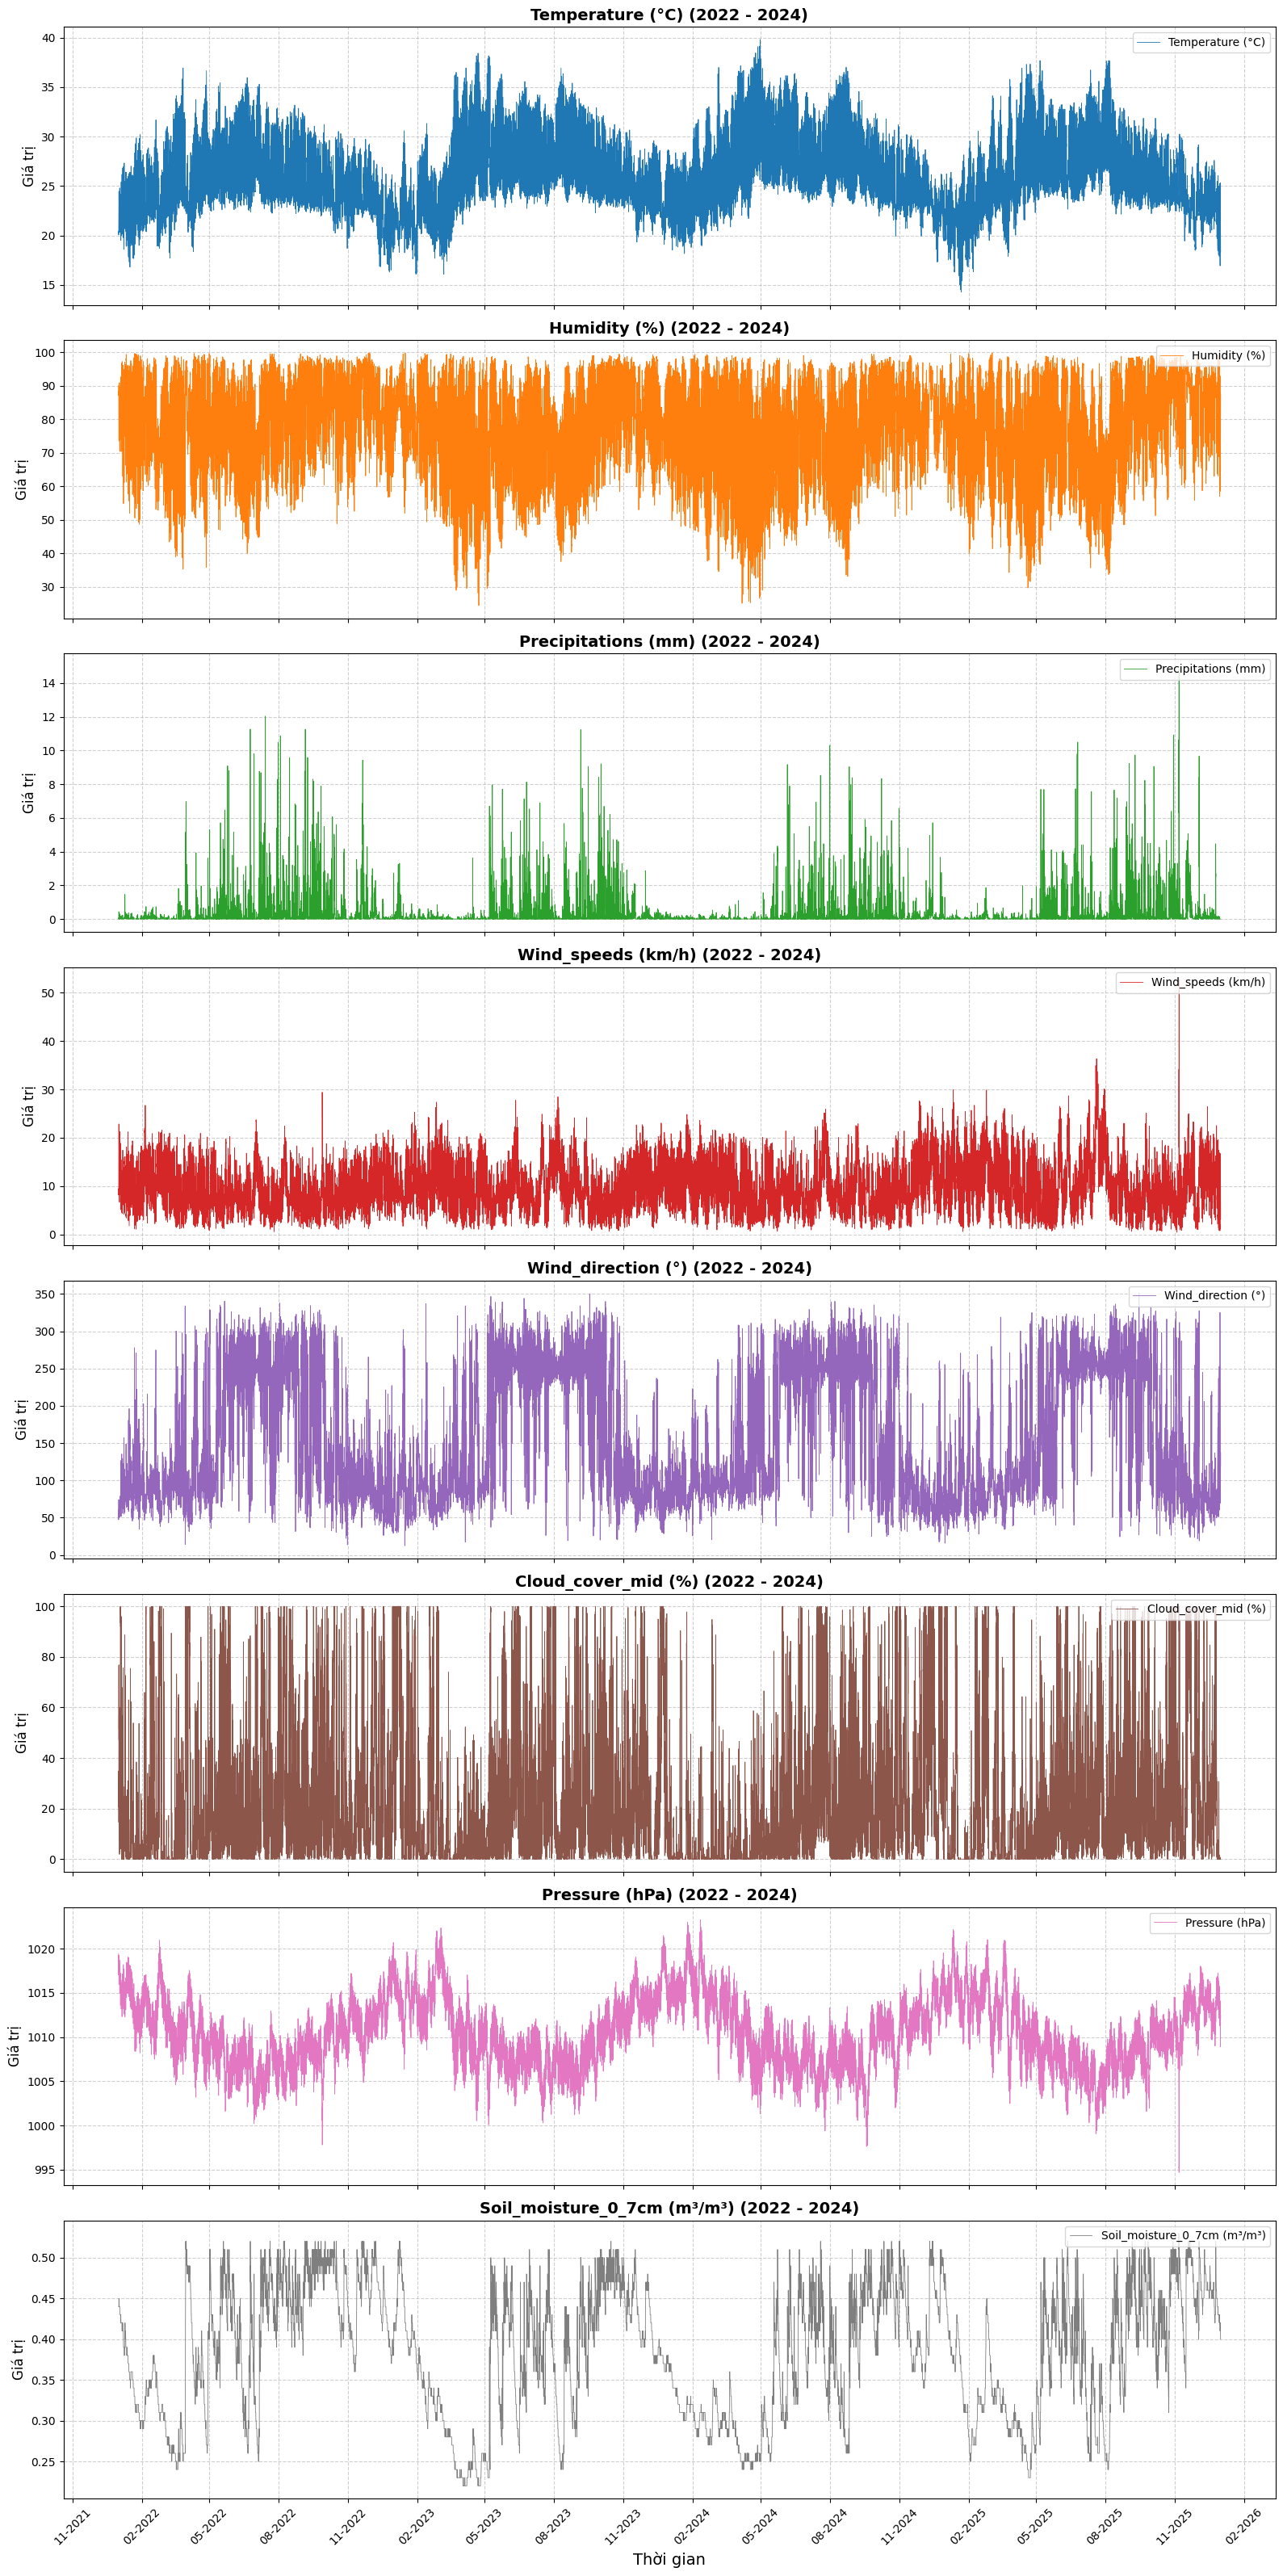

In [19]:
features = df.columns
num_features = len(features)

fig, axes = plt.subplots(nrows=num_features, ncols=1, figsize=(16, 4 * num_features), sharex=True)
fig.subplots_adjust(hspace=0.3)

for i, feature in enumerate(features):
    ax = axes[i]
    ax.plot(df.index, df[feature], label=feature, color=plt.cm.tab10(i % 10), linewidth=0.6)
    
    ax.set_title(f'{feature} (2022 - 2024)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Giá trị', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper right')
    
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))

plt.xlabel('Thời gian', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()